In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [2]:
image_path = "face.jpg"

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [3]:
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

In [4]:
lower = np.array([0, 30, 60], dtype=np.uint8)
upper = np.array([25, 255, 255], dtype=np.uint8)

In [5]:
mask = cv2.inRange(hsv, lower, upper)

In [6]:
kernel = np.ones((3,3), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

In [7]:
skin = cv2.bitwise_and(img, img, mask=mask)

In [8]:
overlay = img.copy()
overlay[mask > 0] = [255, 255, 255]   # show detected skin in white
blended = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

In [9]:
skin_pixels = np.count_nonzero(mask)
total_pixels = mask.shape[0] * mask.shape[1]
skin_percentage = (skin_pixels / total_pixels) * 100

In [ ]:
plt.figure(figsize=(12,8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

(np.float64(-0.5), np.float64(1279.5), np.float64(959.5), np.float64(-0.5))

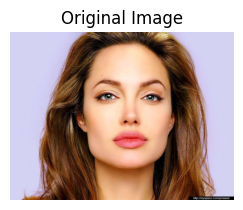

In [11]:
plt.subplot(2,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

(np.float64(-0.5), np.float64(1279.5), np.float64(959.5), np.float64(-0.5))

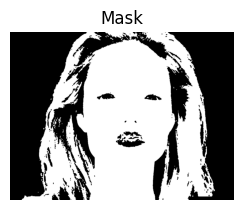

In [12]:
plt.subplot(2,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

(np.float64(-0.5), np.float64(1279.5), np.float64(959.5), np.float64(-0.5))

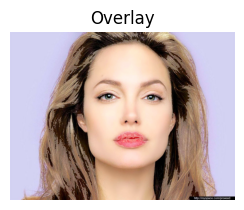

In [13]:
plt.subplot(2,2,3)
plt.imshow(blended)
plt.title("Overlay")
plt.axis("off")

(np.float64(-0.5), np.float64(1279.5), np.float64(959.5), np.float64(-0.5))

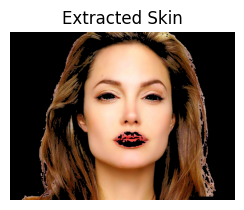

In [14]:
plt.subplot(2,2,4)
plt.imshow(skin)
plt.title("Extracted Skin")
plt.axis("off")

In [15]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>